In [1]:
from transformers import pipeline

model = pipeline("sentiment-analysis")
print(model("I love this project"))

C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'POSITIVE', 'score': 0.999884843826294}]


In [3]:
import requests
from datetime import datetime, timedelta

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"
url = "https://newsapi.org/v2/everything"

# Query parameters
query = "finance AND (stock market OR investment)"
language = "en"
page_size = 100  # max per request

# Date range setup: last 30 days
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

all_articles = []

# Split the 30-day range into 3-day chunks (adjust as needed)
delta = timedelta(days=3)
current_start = start_date

while current_start < end_date:
    current_end = min(current_start + delta, end_date)
    
    page = 1
    while True:
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "from": current_start.strftime("%Y-%m-%d"),
            "to": current_end.strftime("%Y-%m-%d"),
            "apiKey": API_KEY
        }

        response = requests.get(url, params=params)
        data = response.json()

        if "articles" in data and data["articles"]:
            all_articles.extend(data["articles"])
            if len(data["articles"]) < page_size:
                break  # No more pages for this date range
            page += 1
        else:
            break  # No articles for this page/date range

    current_start += delta

# Extract text
news_list = []
for article in all_articles:
    text = article.get("title", "") + " " + str(article.get("description", ""))
    news_list.append(text)

print(f"Total articles fetched: {len(news_list)}")
print(news_list[:10])

Total articles fetched: 883
["An NYC couple went from 'autopilot' to financial independence. They share 3 money moves they made. Financial independence for Josette Chang and Alexander Nathanson came from strategic planning, smart investing, and eliminating mortgage debt.", 'Jim Cramer drops unexpected take on stock market Jim Cramer isn’t buying into the AI doomsday scenario. At a point when Mr. Market had gotten rattled by a viral memo from Citrini Research’s Alap Shah...', "Homeowner Asked Neighbor To Move Fence After Survey Showed It Was 2 Feet Over — But He Refused, Claiming 'Squatter's Rights' Property lines are easy to ignore. Grass grows, fences fade into the background, and everyone assumes the boundary is where it's always been. Then someone...", "Tom Lee: Bitcoin's 50% Drop Is A 'Crypto Squall,' Not A Winter Fundstrat’s Tom Lee called Bitcoin’s (CRYPTO: BTC) 50% drawdown a “crypto squall” rather than a structural collapse, arguing technology and crypto sectors...", "Kalshi sa

In [9]:
# Assuming 'results' is the output of sentiment_model(news_list)
# Map scores to labels
score_map = {"POSITIVE": "Bullish", "NEGATIVE": "Bearish"}

# Count occurrences
sentiment_counts = {"Bullish": 0, "Bearish": 0, "Neutral": 0}

for r in results:
    label = r['label']
    score = r['score']
    
    # Optional: set a threshold for Neutral
    if score < 0.6:
        sentiment_counts["Neutral"] += 1
    else:
        sentiment_counts[score_map[label]] += 1

print(sentiment_counts)

{'Bullish': 323, 'Bearish': 529, 'Neutral': 31}


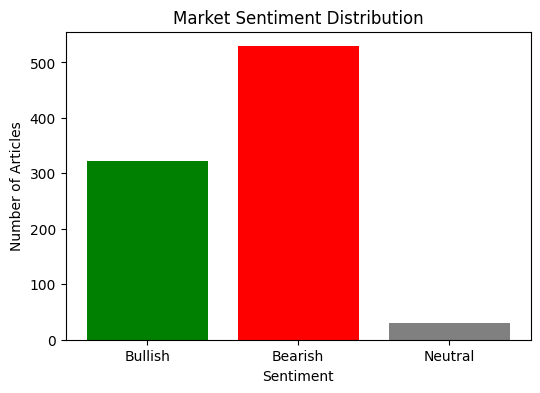

In [11]:
import matplotlib.pyplot as plt

labels = list(sentiment_counts.keys())
counts = list(sentiment_counts.values())

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['green', 'red', 'gray'])
plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.show()